In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("googleplaystore.csv")
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1  

In [26]:
df = df.fillna({
    "Rating": df["Rating"].mean(),
    "Type": "Free",
    "Content Rating": "Everyone",
    "Current Ver": "Varies with device",
    "Android Ver": "4.1 and up"
})
df.isna().any()

,0
App,False
Category,False
Rating,False
Reviews,False
Size,False
Installs,False
Type,False
Price,False
Content Rating,False
Genres,False


In [27]:
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True).str.replace('Free', '0').astype(int)
df = df[df['Reviews'] != '3.0M'].copy()
df['Reviews'] = df['Reviews'].astype(int)


In [28]:
df['Size'] = df['Size'].replace('Varies with device', pd.NA)

def convert_size(size_str):
    if pd.isna(size_str):
        return pd.NA
    size_str = str(size_str).lower()
    if 'm' in size_str:
        return float(size_str.replace('m', ''))
    if 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
    return pd.NA

df['Size_MB'] = df['Size'].apply(convert_size)

# For 'Price' column
df.drop(df[df['Price'] == 'Everyone'].index, inplace=True)
df['Price'] = df['Price'].replace('Free', '0').astype(str).str.replace('$', '', regex=False).astype(float)
df['Size_MB'] = pd.to_numeric(df['Size_MB'], errors='coerce')

In [29]:
print(df.dtypes)
print(df.describe())

App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object
             Rating       Reviews      Installs         Price      Size_MB
count  10840.000000  1.084000e+04  1.084000e+04  10840.000000  9145.000000
mean       4.191972  4.441529e+05  1.546434e+07      1.027368    21.516165
std        0.478907  2.927761e+06  8.502936e+07     15.949703    22.589084
min        1.000000  0.000000e+00  0.000000e+00      0.000000     0.008301
25%        4.100000  3.800000e+01  1.000000e+03      0.000000     4.900000
50%        4.200000  2.094000e+03  1.000000e+05      0.000000    13.000000
75%        4.500000  5.477550e+04  5.000000e+06      0.000000    30.000000
max        5.000000  7

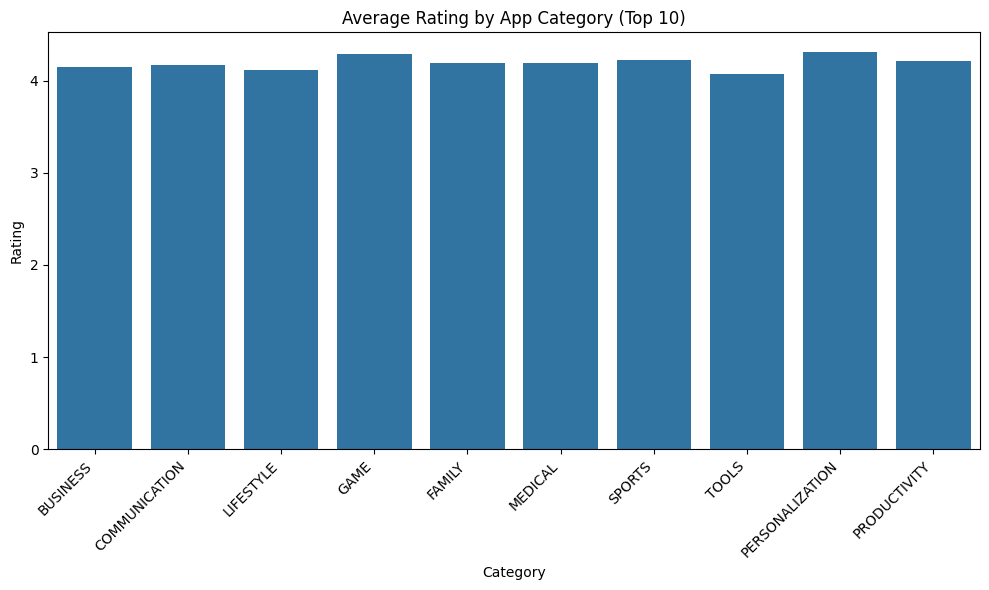

In [30]:
top_categories = df['Category'].value_counts().nlargest(10).index
df_top = df[df['Category'].isin(top_categories)]

plt.figure(figsize=(10,6))
sns.barplot(data=df_top, x='Category', y='Rating', estimator='mean', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title("Average Rating by App Category (Top 10)")
plt.tight_layout()
plt.show()

### Insight: Average Rating by Category
The average rating is very consistent across the top 10 categories, hovering around 4.2–4.3.  
No single category stands out dramatically, suggesting that user satisfaction (as measured by rating)  
does not depend heavily on app category.

In [31]:
from scipy import stats

free_rating = df[df['Type'] == 'Free']['Rating'].dropna()
paid_rating = df[df['Type'] == 'Paid']['Rating'].dropna()

t_stat, p_val = stats.ttest_ind(free_rating, paid_rating, equal_var=False)
print(f"Free mean rating: {free_rating.mean():.2f}")
print(f"Paid mean rating: {paid_rating.mean():.2f}")
print(f"P‑value: {p_val:.6f}")

Free mean rating: 4.19
Paid mean rating: 4.25
P‑value: 0.000309


### Insight: Free vs Paid Rating
- Free apps mean rating: **4.19**  
- Paid apps mean rating: **4.25**  
- P‑value: **0.0003** (far below 0.05)  

We reject the null hypothesis that free and paid apps have the same average rating.  
Paid apps are rated slightly but significantly higher than free apps.  
This could mean users who pay for apps expect higher quality and rate accordingly,  
or that paid apps invest more in quality.

In [32]:
correlation = df['Rating'].corr(df['Installs'])
print(f"Correlation between Rating and Installs: {correlation:.4f}")

Correlation between Rating and Installs: 0.0511


### Insight: Correlation between Rating and Installs
- Correlation coefficient: **0.051**  

There is almost no linear relationship between an app’s rating and its number of installs.  
A high rating does not guarantee millions of downloads, nor does a low rating prevent success.  
Other factors (marketing, category demand, pricing) likely drive installs more than ratings alone.

In [33]:
contingency = pd.crosstab(df['Content Rating'], df['Type'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi‑square p‑value: {p_val:.5f}")

Chi‑square p‑value: 0.00001


### Insight: Content Rating vs Free/Paid
- P‑value: **0.00001** (extremely small)  

We reject the null hypothesis that content rating and app type are independent.  
The type of app (Free or Paid) is strongly associated with its Content Rating (Everyone, Teen, etc.).  
For example, paid apps may be more common in certain content‑rating groups.  
This is a real, statistically significant relationship.

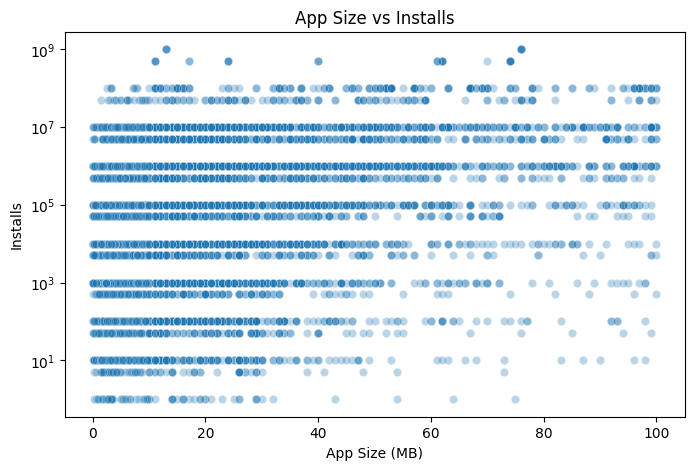

Correlation (Size vs Installs): 0.1648


In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Size_MB', y='Installs', alpha=0.3)
plt.xlabel('App Size (MB)')
plt.ylabel('Installs')
plt.title('App Size vs Installs')
plt.yscale('log')
plt.show()


size_install_corr = df['Size_MB'].corr(df['Installs'])
print(f"Correlation (Size vs Installs): {size_install_corr:.4f}")

### Insight: App Size vs Installs
- Correlation: **0.16** (weak positive)  

There is a slight tendency for larger apps to have more installs, but the relationship is weak.  
Many large apps have few installs, and many small apps are wildly popular.  
App size alone is not a strong predictor of success.

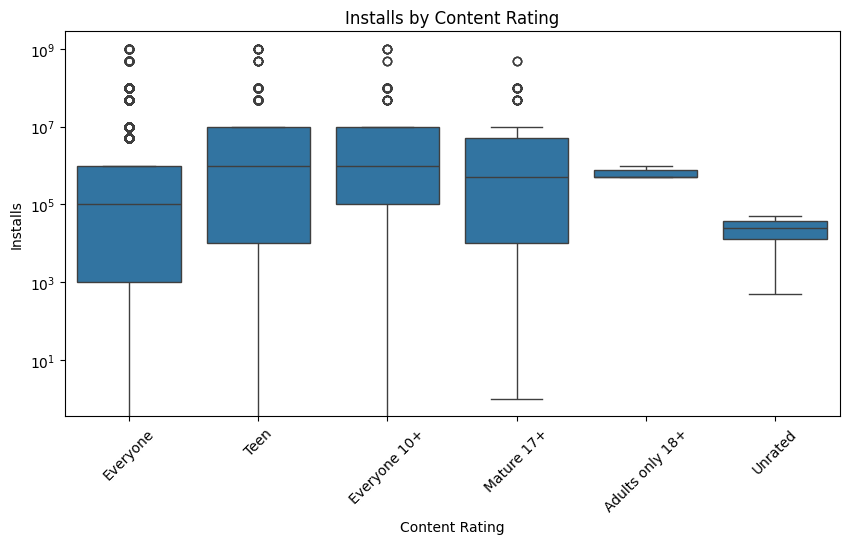

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Content Rating', y='Installs')
plt.yscale('log')
plt.title('Installs by Content Rating')
plt.xticks(rotation=45)
plt.show()

### Insight: Installs by Content Rating
Apps rated for "Everyone" tend to have the highest median installs, which makes sense  
as they reach the widest audience. "Mature" and "Adult" apps have very few installs.  
This is likely because they are restricted in visibility and target a smaller user base.

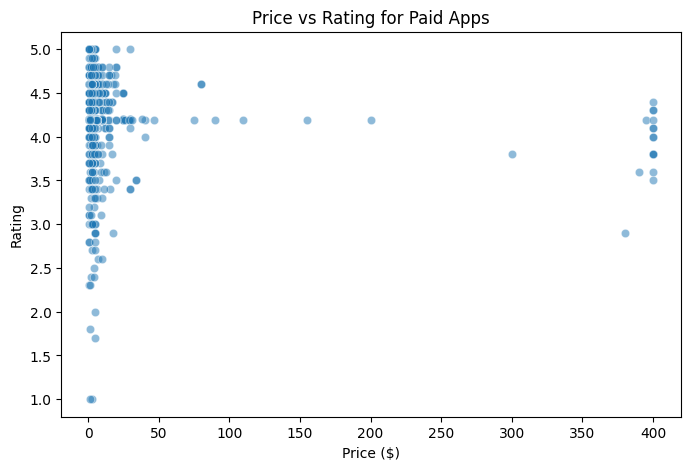

Correlation (Price vs Rating): -0.1041


In [36]:
paid_df = df[df['Type'] == 'Paid'].copy()
plt.figure(figsize=(8,5))
sns.scatterplot(data=paid_df, x='Price', y='Rating', alpha=0.5)
plt.xlabel('Price ($)')
plt.ylabel('Rating')
plt.title('Price vs Rating for Paid Apps')
plt.show()

price_rating_corr = paid_df['Price'].corr(paid_df['Rating'])
print(f"Correlation (Price vs Rating): {price_rating_corr:.4f}")

### Insight: Price vs Rating (Paid Apps)
- Correlation: **-0.10** (weak negative)  

Among paid apps, higher price does not mean higher rating. In fact, there’s a very slight  
tendency for cheaper apps to be rated better. This suggests users judge apps on quality, not on price.

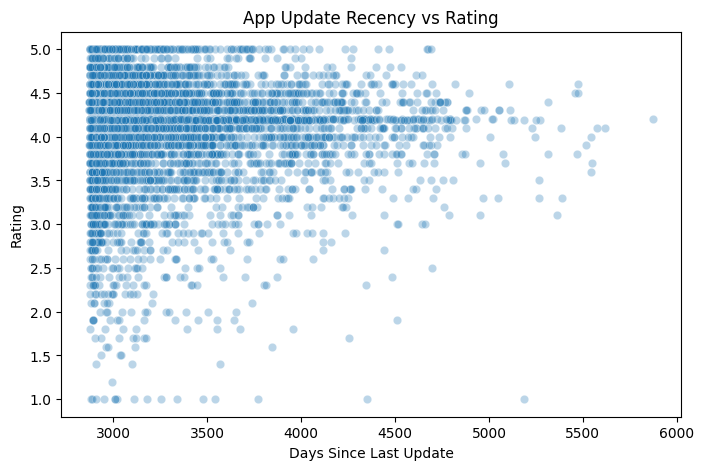

Correlation (Update Recency vs Rating): -0.1333


In [37]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Days_Since_Update'] = (pd.Timestamp('2026-06-20') - df['Last Updated']).dt.days


plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Days_Since_Update', y='Rating', alpha=0.3)
plt.xlabel('Days Since Last Update')
plt.ylabel('Rating')
plt.title('App Update Recency vs Rating')
plt.show()

update_rating_corr = df['Days_Since_Update'].corr(df['Rating'])
print(f"Correlation (Update Recency vs Rating): {update_rating_corr:.4f}")

### Insight: Update Recency vs Rating
- Correlation: **-0.13** (weak negative)  

Apps that were updated more recently tend to have slightly higher ratings.  
This could be because developers who update their apps more often also fix bugs and  
respond to user feedback, leading to better user satisfaction.

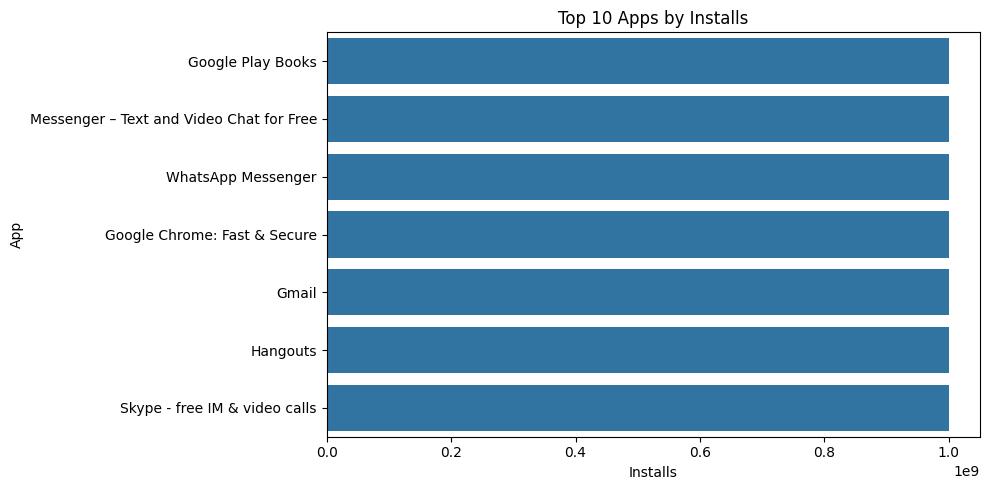

In [38]:
top10_installs = df.nlargest(10, 'Installs')[['App', 'Installs']]
plt.figure(figsize=(10,5))
sns.barplot(data=top10_installs, x='Installs', y='App')
plt.title('Top 10 Apps by Installs')
plt.xlabel('Installs')
plt.tight_layout()
plt.show()

### Insight: Top 10 Most Installed Apps
These are mostly utility and communication apps (Google, WhatsApp, etc.) with billions of installs.  
They dominate the Play Store and reflect the importance of being a pre‑installed or essential service.